# Week 6 Assignment — Prediction Shootout + Project Proposal
## Part A: 雙事件內插比較

本作業比較兩個不同型態的降雨事件：
1. 凱米颱風（2024/07/25）
2. 梅雨鋒面事件（2024/05/21–2024/05/24 擇一）

分析內容包括：
- A0. 資料蒐集與前處理
- A1. Variogram 分析
- A2. 四種方法內插
- A3. 不確定性分析
- A4. GeoTIFF 輸出
- A5. 跨事件綜合比較

### 選擇分析時間點（凱米颱風）

由於原始資料為時間序列資料，本研究選擇單一時間點進行空間內插分析。

本案例選擇凱米颱風期間降雨較強時段，使用「Past1hr」作為分析變數。

本研究選擇 2024-07-25 04:30 作為分析時點，
因該時刻之平均降雨量為所有時間中最高，
且降雨分布相對均勻（未受極端單點影響），
可有效反映區域性降雨空間結構，適合進行空間內插分析。

## A0. 資料蒐集

本研究選擇兩種不同型態的降雨事件進行比較：
1. **凱米颱風（2024/07/25）**
2. **梅雨鋒面事件（2024/05/21–2024/05/24，後續擇一）**

研究範圍設定為 **宜蘭縣與花蓮縣**。  
本節工作包括：

1. 讀取鄉鎮市區界線資料
2. 篩選宜蘭縣與花蓮縣作為研究區
3. 讀取颱風事件雨量資料
4. 以各時間點平均雨量（Past1hr）選擇代表性分析時間
5. 篩選單一時間點資料
6. 移除無效值與 0 雨量測站
7. 建立 GeoDataFrame，並轉換至 EPSG:3826，作為後續 Kriging 與其他空間內插分析之輸入資料

=== towns columns ===
['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']
CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Rows: 368

=== study area ===
COUNTYNAME
花蓮縣    13
宜蘭縣    12
Name: count, dtype: int64


c:\Users\User\anaconda3\envs\gis-env\Lib\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 23452 (\N{CJK UNIFIED IDEOGRAPH-5B9C}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\User\anaconda3\envs\gis-env\Lib\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 34349 (\N{CJK UNIFIED IDEOGRAPH-862D}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\User\anaconda3\envs\gis-env\Lib\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\User\anaconda3\envs\gis-env\Lib\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 33457 (\N{CJK UNIFIED IDEOGRAPH-82B1}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\User\anaconda3\envs\gis-env\Lib\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 34030 (\N{CJK UNIFIED IDEOGRAPH-84EE}) missing from font(s) DejaVu Sans.
  ax.f

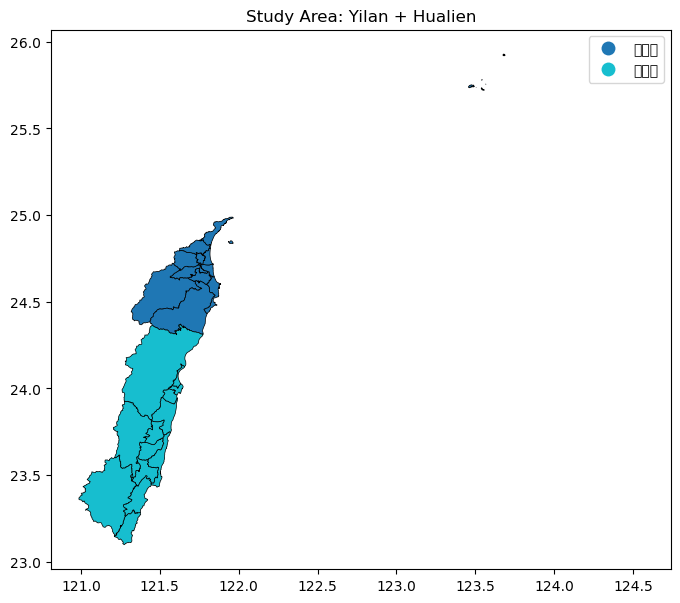


=== typhoon columns ===
['StationId', 'StationName', 'CountyName', 'TownName', 'StationLatitude', 'StationLongitude', 'StationAltitude', 'DateTime', 'Past1hr', 'Past10Min', 'Past3hr', 'Past6hr', 'Past12hr', 'Past24hr', 'NOW', 'Past2days', 'Past3days']
Shape: (162510, 17)


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,StationAltitude,DateTime,Past1hr,Past10Min,Past3hr,Past6hr,Past12hr,Past24hr,NOW,Past2days,Past3days
0,CAP060,國三S385K,高雄市,大樹區,22.767776,120.444440,93.0,2024-07-25 00:00:00,21.0,11.5,59.5,84.0,167.5,210.5,210.5,217.5,217.5
1,466940,基隆,基隆市,仁愛區,25.133314,121.740480,26.7,2024-07-25 00:00:00,2.0,0.0,4.0,8.0,40.5,61.0,61.0,64.5,64.5
2,466900,淡水,新北市,淡水區,25.164888,121.448906,19.0,2024-07-25 00:00:00,0.0,0.0,0.0,6.5,69.0,112.0,112.0,112.5,112.5
3,466881,新北,新北市,新店區,24.959328,121.524330,24.1,2024-07-25 00:00:00,1.0,0.0,2.5,13.5,88.5,185.5,185.5,197.0,197.0
4,466930,陽明山,臺北市,北投區,25.162079,121.544550,607.1,2024-07-25 00:00:00,0.5,0.0,5.0,13.5,119.0,208.5,208.5,214.5,214.5



=== Top 10 rainfall times ===


,DateTime,mean,sum,max
27,2024-07-25 04:30:00,12.784411,14433.6,82.0
28,2024-07-25 04:40:00,12.766519,14413.4,90.0
26,2024-07-25 04:20:00,12.765368,14412.1,75.0
30,2024-07-25 05:00:00,12.713640,14353.7,101.0
29,2024-07-25 04:50:00,12.694597,14332.2,99.5
31,2024-07-25 05:10:00,12.326726,13929.2,102.5
25,2024-07-25 04:10:00,12.322941,13912.6,73.5
24,2024-07-25 04:00:00,12.293091,13878.9,73.5
23,2024-07-25 03:50:00,12.286195,13883.4,76.5
43,2024-07-25 07:10:00,12.222961,13787.5,72.0


Selected time: 2024-07-25 04:30:00

Rows after time filter: 1129


...

,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,StationAltitude,DateTime,Past1hr,Past10Min,Past3hr,Past6hr,Past12hr,Past24hr,NOW,Past2days,Past3days,geometry
30570,C0R570,麟洛,屏東縣,麟洛鄉,22.650776,120.527190,37.0,2024-07-25 04:30:00,16.5,2.0,32.5,98.0,157.0,287.0,64.0,287.0,300.5,POINT (120.52719 22.65078)
30571,C1I230,九份二山,南投縣,國姓鄉,23.962025,120.845270,837.0,2024-07-25 04:30:00,57.0,9.0,130.5,169.0,206.5,237.5,159.0,258.5,264.5,POINT (120.84527 23.96202)
30572,466940,基隆,基隆市,仁愛區,25.133314,121.740480,26.7,2024-07-25 04:30:00,0.5,0.0,5.0,10.5,33.0,59.5,8.0,69.0,72.5,POINT (121.74048 25.13331)
30573,466900,淡水,新北市,淡水區,25.164888,121.448906,19.0,2024-07-25 04:30:00,1.5,0.0,1.5,2.0,32.0,108.0,2.0,114.0,114.5,POINT (121.44891 25.16489)
30574,466881,新北,新北市,新店區,24.959328,121.524330,24.1,2024-07-25 04:30:00,1.0,0.0,6.5,12.5,52.5,162.5,10.5,196.0,207.5,POINT (121.52433 24.95933)



=== After study area filter ===
Rows: 137


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,StationAltitude,DateTime,Past1hr,Past10Min,...,Past6hr,Past12hr,Past24hr,NOW,Past2days,Past3days,geometry,index_right,COUNTYNAME,TOWNNAME
30587,467080,宜蘭,宜蘭縣,宜蘭市,24.763975,121.756530,7.4,2024-07-25 04:30:00,2.5,0.0,...,18.0,91.5,192.0,15.5,204.5,271.0,POINT (121.75653 24.76398),20,宜蘭縣,宜蘭市
30588,466990,花蓮,花蓮縣,花蓮市,23.975128,121.613270,16.1,2024-07-25 04:30:00,3.5,0.5,...,23.0,260.5,318.0,18.5,344.0,382.5,POINT (121.61327 23.97513),337,花蓮縣,花蓮市
30721,C1U670,寒溪,宜蘭縣,冬山鄉,24.634003,121.716910,105.0,2024-07-25 04:30:00,1.5,0.5,...,41.5,152.0,305.5,36.0,329.5,375.0,POINT (121.71691 24.634),27,宜蘭縣,冬山鄉
30722,C0U520,雙連埤,宜蘭縣,員山鄉,24.753033,121.641304,517.0,2024-07-25 04:30:00,1.0,0.0,...,31.0,103.0,192.5,26.5,208.0,305.5,POINT (121.6413 24.75303),26,宜蘭縣,員山鄉
30724,C0U600,礁溪,宜蘭縣,礁溪鄉,24.817540,121.765610,10.0,2024-07-25 04:30:00,2.0,0.5,...,17.0,79.0,160.0,14.0,168.0,222.0,POINT (121.76561 24.81754),272,宜蘭縣,礁溪鄉



=== Final typhoon dataset for interpolation ===
CRS: EPSG:3826
Rows: 137


,StationId,StationName,CountyName,TownName,Past1hr,x,y
30587,467080,宜蘭,宜蘭縣,宜蘭市,2.5,326510.822124,2.739847e+06
30588,466990,花蓮,花蓮縣,花蓮市,3.5,312407.860581,2.652404e+06
30721,C1U670,寒溪,宜蘭縣,冬山鄉,1.5,322579.028499,2.725429e+06
30722,C0U520,雙連埤,宜蘭縣,員山鄉,1.0,314862.903137,2.738576e+06
30724,C0U600,礁溪,宜蘭縣,礁溪鄉,2.0,327395.908378,2.745785e+06


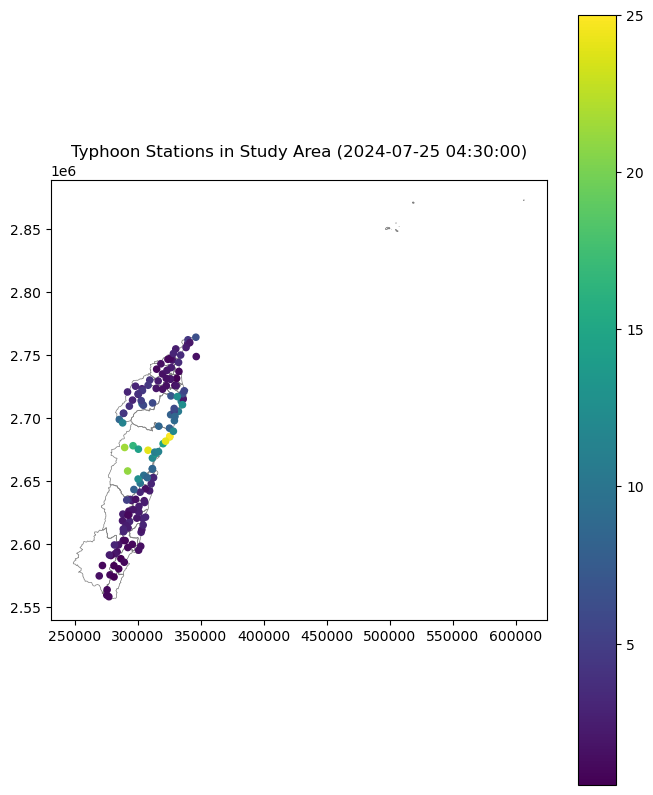


A0 complete.


In [1]:
# =========================
# A0. 資料蒐集（完整版）
# =========================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# -------------------------
# 0. 基本路徑設定
# -------------------------
PROJECT_DIR = r"C:\Users\User\CascadeProjects\week6_HW"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
RASTER_DIR = os.path.join(OUTPUT_DIR, "rasters")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")

for folder in [OUTPUT_DIR, FIG_DIR, RASTER_DIR, TABLE_DIR]:
    os.makedirs(folder, exist_ok=True)

# -------------------------
# 1. 讀取鄉鎮市區界線
# -------------------------
town_shp = os.path.join(
    DATA_DIR,
    "鄉(鎮、市、區)界線1140318",
    "TOWN_MOI_1140318.shp"
)

towns = gpd.read_file(town_shp)

print("=== towns columns ===")
print(towns.columns.tolist())
print("CRS:", towns.crs)
print("Rows:", len(towns))

# -------------------------
# 2. 篩選研究區（宜蘭 + 花蓮）
# -------------------------
study_towns = towns[towns["COUNTYNAME"].isin(["宜蘭縣", "花蓮縣"])].copy()

print("\n=== study area ===")
print(study_towns["COUNTYNAME"].value_counts())

fig, ax = plt.subplots(figsize=(8, 10))
study_towns.plot(ax=ax, column="COUNTYNAME", legend=True, edgecolor="black", linewidth=0.5)
ax.set_title("Study Area: Yilan + Hualien")
plt.show()

# -------------------------
# 3. 讀取凱米颱風資料
# -------------------------
typhoon_file = os.path.join(DATA_DIR, "rain_20240725.csv")
df_ty = pd.read_csv(typhoon_file, encoding="utf-8-sig")

print("\n=== typhoon columns ===")
print(df_ty.columns.tolist())
print("Shape:", df_ty.shape)
display(df_ty.head())

# -------------------------
# 4. 用 Past1hr 挑選代表性分析時間
# -------------------------
rain_stats = (
    df_ty.groupby("DateTime")["Past1hr"]
    .agg(["mean", "sum", "max"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

print("\n=== Top 10 rainfall times ===")
display(rain_stats.head(10))

# 根據前面分析結果，選擇平均雨量最高且分布較穩定的時間
selected_time = "2024-07-25 04:30:00"
print("Selected time:", selected_time)

# -------------------------
# 5. 篩選單一時間點資料
# -------------------------
df_ty_time = df_ty[df_ty["DateTime"] == selected_time].copy()

print("\nRows after time filter:", len(df_ty_time))
display(df_ty_time.head())

# -------------------------
# 6. 清理雨量資料
#    - 去除 0
#    - 若有 -998 也一併排除
# -------------------------
print("\n=== Before cleaning ===")
print("Rows:", len(df_ty_time))
print("Count of -998:", (df_ty_time["Past1hr"] == -998).sum())
print("Count of 0:", (df_ty_time["Past1hr"] == 0).sum())
print(df_ty_time["Past1hr"].describe())

df_ty_clean = df_ty_time[(df_ty_time["Past1hr"] > 0) & (df_ty_time["Past1hr"] != -998)].copy()

print("\n=== After cleaning ===")
print("Rows:", len(df_ty_clean))
print("Removed:", len(df_ty_time) - len(df_ty_clean))

# -------------------------
# 7. 建立 GeoDataFrame（WGS84）
# -------------------------
gdf_ty = gpd.GeoDataFrame(
    df_ty_clean.copy(),
    geometry=gpd.points_from_xy(
        df_ty_clean["StationLongitude"],
        df_ty_clean["StationLatitude"]
    ),
    crs="EPSG:4326"
)

print("\nTyphoon GDF CRS:", gdf_ty.crs)
display(gdf_ty.head())

# -------------------------
# 8. 只保留研究區（宜蘭 + 花蓮）
#    先用屬性欄位篩選，再用 polygon 檢查
# -------------------------
gdf_ty = gdf_ty[gdf_ty["CountyName"].isin(["宜蘭縣", "花蓮縣"])].copy()

study_towns_wgs84 = study_towns.to_crs(gdf_ty.crs)

gdf_ty = gpd.sjoin(
    gdf_ty,
    study_towns_wgs84[["COUNTYNAME", "TOWNNAME", "geometry"]],
    how="inner",
    predicate="within"
).copy()

print("\n=== After study area filter ===")
print("Rows:", len(gdf_ty))
display(gdf_ty.head())

# -------------------------
# 9. 轉 EPSG:3826（Kriging 必須）
# -------------------------
gdf_ty_3826 = gdf_ty.to_crs(epsg=3826).copy()
gdf_ty_3826["x"] = gdf_ty_3826.geometry.x
gdf_ty_3826["y"] = gdf_ty_3826.geometry.y
gdf_ty_3826["rain"] = pd.to_numeric(gdf_ty_3826["Past1hr"], errors="coerce")

print("\n=== Final typhoon dataset for interpolation ===")
print("CRS:", gdf_ty_3826.crs)
print("Rows:", len(gdf_ty_3826))
display(gdf_ty_3826[[
    "StationId", "StationName", "CountyName", "TownName",
    "Past1hr", "x", "y"
]].head())

# -------------------------
# 10. 快速視覺檢查
# -------------------------
fig, ax = plt.subplots(figsize=(8, 10))
study_towns.to_crs(epsg=3826).plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.5)
gdf_ty_3826.plot(ax=ax, column="rain", legend=True, markersize=20)
ax.set_title(f"Typhoon Stations in Study Area ({selected_time})")
plt.show()

# -------------------------
# 11. 儲存可重用成果
# -------------------------
gdf_ty_3826.to_file(os.path.join(OUTPUT_DIR, "typhoon_points_3826.geojson"), driver="GeoJSON")

rain_stats.to_csv(
    os.path.join(TABLE_DIR, "typhoon_time_selection_stats.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\nA0 complete.")

### 梅雨事件選取邏輯（均勻型降雨）

為了與颱風之集中型強降雨形成對比，本研究不以單一時間點之最大平均雨量作為梅雨事件選取依據，
而改以「均勻型降雨」特徵進行判斷。

本研究針對 2024/05/21–2024/05/24 各時間點，計算以下指標：
- 平均雨量（mean）
- 最大值與平均值比（max/mean）
- 有雨測站比例（wet_ratio）
- 變異係數（cv = std/mean）

其中，較符合梅雨鋒面特性的時間點應具有：
1. 較高之平均雨量
2. 較高之有雨測站比例
3. 較低之極端值集中程度（max/mean 較低）
4. 較低之空間變異（cv 較低）

因此，本研究據此挑選最具代表性的均勻型降雨時刻作為梅雨事件分析時點。

=== Top 15 candidate Meiyu times ===


,file,DateTime,mean,wet_ratio,cv,peak_ratio,meiyu_score
108,rain_20240521.csv,2024-05-21 18:10:00,3.056349,0.355379,1.990559,12.433134,0.955964
105,rain_20240521.csv,2024-05-21 17:40:00,3.106322,0.379341,2.344629,18.993521,0.950299
107,rain_20240521.csv,2024-05-21 18:00:00,2.987588,0.371479,2.082867,16.735909,0.949488
106,rain_20240521.csv,2024-05-21 17:50:00,2.978164,0.377897,2.247204,19.810863,0.936152
109,rain_20240521.csv,2024-05-21 18:20:00,2.965843,0.354810,1.989234,15.509925,0.935201
104,rain_20240521.csv,2024-05-21 17:30:00,3.149199,0.368327,2.479678,22.069102,0.924017
110,rain_20240521.csv,2024-05-21 18:30:00,2.859629,0.354240,2.031063,17.834481,0.910710
103,rain_20240521.csv,2024-05-21 17:20:00,2.991556,0.364444,2.562109,25.237706,0.882840
111,rain_20240521.csv,2024-05-21 18:40:00,2.711229,0.342175,2.087295,17.335312,0.871229
102,rain_20240521.csv,2024-05-21 17:10:00,2.809503,0.345471,2.589069,24.559507,0.832453


Selected Meiyu day : rain_20240521.csv
Selected Meiyu time: 2024-05-21 18:10:00

Rows before cleaning: 1134
Count of 0: 731
Rows after cleaning: 403
Rows after spatial filter: 81

Final Meiyu dataset: 81


,StationId,StationName,CountyName,TownName,Past1hr,x,y
122710,81T770,大豐,花蓮縣,光復鄉,3.5,288381.872782,2.611576e+06
122711,81T990,高山部落,花蓮縣,豐濱鄉,2.0,306034.363139,2.621015e+06
122715,C0UB10,蘇澳,宜蘭縣,蘇澳鎮,0.5,336796.479206,2.721406e+06
122736,467080,宜蘭,宜蘭縣,宜蘭市,6.0,326510.822124,2.739847e+06
122737,466990,花蓮,花蓮縣,花蓮市,1.0,312407.860581,2.652404e+06


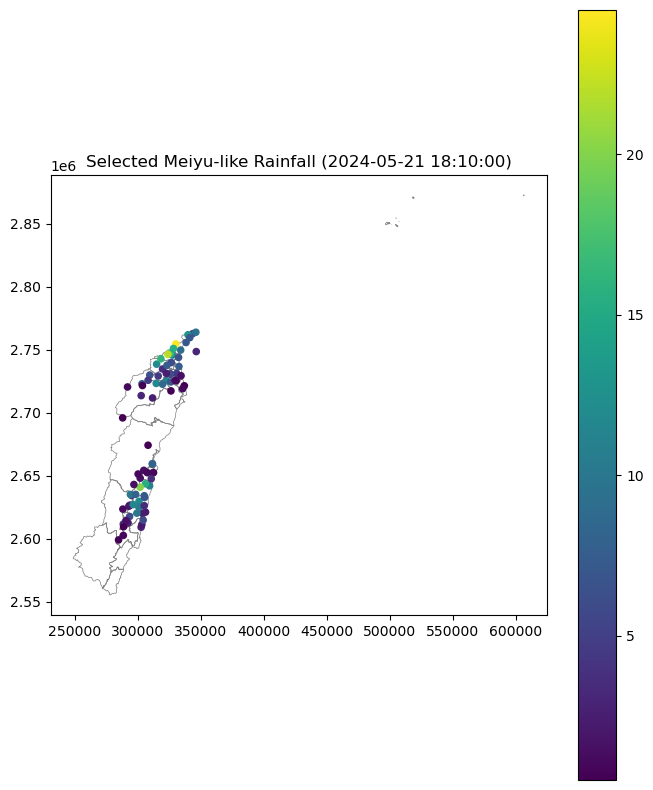

In [2]:
# =========================
# A0（梅雨事件：均勻型降雨選取版）
# =========================

mei_files = [
    "rain_20240521.csv",
    "rain_20240522.csv",
    "rain_20240523.csv",
    "rain_20240524.csv"
]

all_stats = []

for f in mei_files:
    file_path = os.path.join(DATA_DIR, f)
    df = pd.read_csv(file_path, encoding="utf-8-sig").copy()

    # 時間與雨量格式
    df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
    df["Past1hr"] = pd.to_numeric(df["Past1hr"], errors="coerce")

    # -998 視為缺值
    df.loc[df["Past1hr"] == -998, "Past1hr"] = np.nan
    df = df.dropna(subset=["DateTime", "Past1hr"]).copy()

    # 每個時間點做統計
    for dt, sub in df.groupby("DateTime"):
        rain = sub["Past1hr"].copy()

        mean_val = rain.mean()
        std_val = rain.std()
        max_val = rain.max()
        wet_ratio = (rain > 0).mean()   # 有雨站比例
        cv = std_val / mean_val if mean_val > 0 else np.nan
        peak_ratio = max_val / mean_val if mean_val > 0 else np.nan

        all_stats.append({
            "file": f,
            "DateTime": dt,
            "mean": mean_val,
            "std": std_val,
            "max": max_val,
            "wet_ratio": wet_ratio,
            "cv": cv,
            "peak_ratio": peak_ratio
        })

stats_df = pd.DataFrame(all_stats)

# 只保留平均雨量有意義的時間點，避免全場小雨或幾乎沒雨
stats_df = stats_df[stats_df["mean"] >= 1.0].copy()

# 標準化分數：高 mean / 高 wet_ratio / 低 cv / 低 peak_ratio 較像梅雨
def minmax_scale(series):
    s = series.copy()
    if s.max() == s.min():
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

stats_df["score_mean"] = minmax_scale(stats_df["mean"])
stats_df["score_wet"] = minmax_scale(stats_df["wet_ratio"])
stats_df["score_cv"] = 1 - minmax_scale(stats_df["cv"])               # 越低越好
stats_df["score_peak"] = 1 - minmax_scale(stats_df["peak_ratio"])     # 越低越好

# 綜合分數：偏重「均勻 + 持續」
stats_df["meiyu_score"] = (
    0.30 * stats_df["score_mean"] +
    0.30 * stats_df["score_wet"] +
    0.20 * stats_df["score_cv"] +
    0.20 * stats_df["score_peak"]
)

stats_df_sorted = stats_df.sort_values("meiyu_score", ascending=False).copy()

print("=== Top 15 candidate Meiyu times ===")
display(
    stats_df_sorted[
        ["file", "DateTime", "mean", "wet_ratio", "cv", "peak_ratio", "meiyu_score"]
    ].head(15)
)

# 選出最像梅雨的時間
best_row = stats_df_sorted.iloc[0]
best_file = best_row["file"]
selected_time_mei = best_row["DateTime"]

print("Selected Meiyu day :", best_file)
print("Selected Meiyu time:", selected_time_mei)

# -------------------------
# 讀取最佳日期並篩選該時間
# -------------------------
mei_file = os.path.join(DATA_DIR, best_file)
df_mei = pd.read_csv(mei_file, encoding="utf-8-sig").copy()

df_mei["DateTime"] = pd.to_datetime(df_mei["DateTime"], errors="coerce")
df_mei["Past1hr"] = pd.to_numeric(df_mei["Past1hr"], errors="coerce")
df_mei.loc[df_mei["Past1hr"] == -998, "Past1hr"] = np.nan

df_mei = df_mei.dropna(subset=["DateTime", "Past1hr"]).copy()

df_mei_time = df_mei[df_mei["DateTime"] == selected_time_mei].copy()

print("\nRows before cleaning:", len(df_mei_time))
print("Count of 0:", (df_mei_time["Past1hr"] == 0).sum())

# 梅雨最終仍只留 > 0
df_mei_clean = df_mei_time[df_mei_time["Past1hr"] > 0].copy()

print("Rows after cleaning:", len(df_mei_clean))

# -------------------------
# GeoDataFrame
# -------------------------
gdf_mei = gpd.GeoDataFrame(
    df_mei_clean,
    geometry=gpd.points_from_xy(
        df_mei_clean["StationLongitude"],
        df_mei_clean["StationLatitude"]
    ),
    crs="EPSG:4326"
)

# 只留研究區
gdf_mei = gdf_mei[gdf_mei["CountyName"].isin(["宜蘭縣", "花蓮縣"])].copy()

study_towns_wgs84 = study_towns.to_crs(gdf_mei.crs)

gdf_mei = gpd.sjoin(
    gdf_mei,
    study_towns_wgs84[["COUNTYNAME", "TOWNNAME", "geometry"]],
    how="inner",
    predicate="within"
).copy()

print("Rows after spatial filter:", len(gdf_mei))

# 轉 3826
gdf_mei_3826 = gdf_mei.to_crs(epsg=3826).copy()
gdf_mei_3826["x"] = gdf_mei_3826.geometry.x
gdf_mei_3826["y"] = gdf_mei_3826.geometry.y
gdf_mei_3826["rain"] = pd.to_numeric(gdf_mei_3826["Past1hr"], errors="coerce")

print("\nFinal Meiyu dataset:", len(gdf_mei_3826))
display(
    gdf_mei_3826[
        ["StationId", "StationName", "CountyName", "TownName", "Past1hr", "x", "y"]
    ].head()
)

# 快速視覺檢查
fig, ax = plt.subplots(figsize=(8, 10))
study_towns.to_crs(epsg=3826).plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.5)
gdf_mei_3826.plot(ax=ax, column="rain", legend=True, markersize=20)
ax.set_title(f"Selected Meiyu-like Rainfall ({selected_time_mei})")
plt.show()

In [4]:
# =========================
# 11. 儲存可重用成果（Meiyu）
# =========================

# 1️⃣ 空間點資料（GeoJSON）
gdf_mei_3826.to_file(
    os.path.join(OUTPUT_DIR, "meiyu_points_3826.geojson"),
    driver="GeoJSON"
)

# 2️⃣ 統計表（CSV）
stats_df_sorted.to_csv(
    os.path.join(TABLE_DIR, "meiyu_time_selection_stats.csv"),
    index=False,
    encoding="utf-8-sig"
)

# 3️⃣ 統計表（JSON）
stats_df_sorted.to_json(
    os.path.join(TABLE_DIR, "meiyu_time_selection_stats.json"),
    orient="records",
    force_ascii=False,
    indent=2
)

print("✅ Meiyu outputs saved")

✅ Meiyu outputs saved


C:\Users\User\AppData\Local\Temp\ipykernel_25436\716426422.py:19: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  stats_df_sorted.to_json(


In [4]:
stats_df_sorted[
    ["file", "DateTime", "mean", "wet_ratio", "cv", "peak_ratio", "meiyu_score"]
].head(10)

,file,DateTime,mean,wet_ratio,cv,peak_ratio,meiyu_score
108,rain_20240521.csv,2024-05-21 18:10:00,3.056349,0.355379,1.990559,12.433134,0.955964
105,rain_20240521.csv,2024-05-21 17:40:00,3.106322,0.379341,2.344629,18.993521,0.950299
107,rain_20240521.csv,2024-05-21 18:00:00,2.987588,0.371479,2.082867,16.735909,0.949488
106,rain_20240521.csv,2024-05-21 17:50:00,2.978164,0.377897,2.247204,19.810863,0.936152
109,rain_20240521.csv,2024-05-21 18:20:00,2.965843,0.354810,1.989234,15.509925,0.935201
104,rain_20240521.csv,2024-05-21 17:30:00,3.149199,0.368327,2.479678,22.069102,0.924017
110,rain_20240521.csv,2024-05-21 18:30:00,2.859629,0.354240,2.031063,17.834481,0.910710
103,rain_20240521.csv,2024-05-21 17:20:00,2.991556,0.364444,2.562109,25.237706,0.882840
111,rain_20240521.csv,2024-05-21 18:40:00,2.711229,0.342175,2.087295,17.335312,0.871229
102,rain_20240521.csv,2024-05-21 17:10:00,2.809503,0.345471,2.589069,24.559507,0.832453


本研究原擬選取梅雨鋒面降雨作為均勻型降雨之代表，
並與颱風之集中型降雨進行比較。

然而，針對 2024 年 5 月下旬降雨事件分析發現，
其 wet_ratio 約為 0.3–0.4，顯示降雨僅分布於部分測站，
同時 peak_ratio 與變異係數（cv）偏高，
顯示降雨具有顯著空間集中性。

此結果與氣象資料指出 2024 年梅雨季降雨偏少，
且降雨型態偏向短時強降雨（對流性降雨）之特徵一致。

因此，本研究認為該期間降雨事件
未呈現典型梅雨鋒面之均勻降雨特性，
而是呈現「對流化梅雨」之特徵，
並據此與颱風降雨進行比較分析。

## A1. Variogram 分析（兩個事件各做一次）

本節針對颱風事件與梅雨事件分別建立 experimental variogram，
並比較兩種理論模型（spherical 與 exponential）的擬合結果。
接著以擬合誤差（RMSE）較低者作為最佳模型，
並比較兩事件之 sill、range 與 nugget 差異，
以說明不同降雨型態下之空間變異結構。

Typhoon points: 137
Meiyu points  : 81


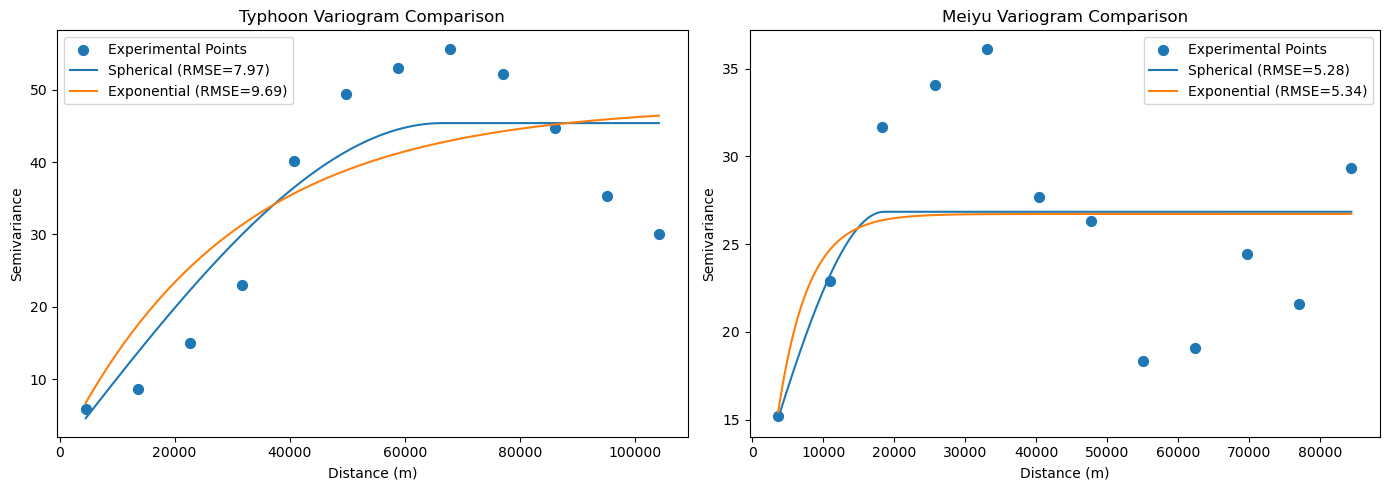

=== Variogram Model Comparison ===


,Event,Model,Nugget,Partial_Sill,Total_Sill,Range,RMSE
0,Typhoon,spherical,3.821335e-36,45.373545,45.373545,66499.124327,7.967416
1,Typhoon,exponential,1.111255e-32,47.855523,47.855523,29813.393843,9.690550
2,Meiyu,spherical,1.022632e+01,16.614578,26.840893,18585.315655,5.278968
3,Meiyu,exponential,7.139100e-12,26.718018,26.718018,4253.383961,5.343824


=== Best Model Table ===


,Event,Best_Model,Nugget,Partial_Sill,Total_Sill,Range,RMSE
0,Typhoon,spherical,3.821335e-36,45.373545,45.373545,66499.124327,7.967416
1,Meiyu,spherical,1.022632e+01,16.614578,26.840893,18585.315655,5.278968


In [5]:
# =========================
# A1. Variogram 分析
# 需求：
# 1. 每個事件比較 spherical + exponential
# 2. 畫出 experimental points + 兩種擬合曲線
# 3. 選最佳模型（RMSE 較低）
# 4. 比較兩事件 sill / range / nugget
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.optimize import curve_fit

# -------------------------
# 0. 防呆：確認欄位存在
# -------------------------
for name, gdf in [("Typhoon", gdf_ty_3826), ("Meiyu", gdf_mei_3826)]:
    for col in ["x", "y", "rain"]:
        if col not in gdf.columns:
            raise ValueError(f"{name} dataset missing column: {col}")

# 數值化 + 去缺值
gdf_ty = gdf_ty_3826.copy()
gdf_ty["rain"] = pd.to_numeric(gdf_ty["rain"], errors="coerce")
gdf_ty = gdf_ty.dropna(subset=["x", "y", "rain"]).copy()

gdf_mei = gdf_mei_3826.copy()
gdf_mei["rain"] = pd.to_numeric(gdf_mei["rain"], errors="coerce")
gdf_mei = gdf_mei.dropna(subset=["x", "y", "rain"]).copy()

print("Typhoon points:", len(gdf_ty))
print("Meiyu points  :", len(gdf_mei))

# -------------------------
# 1. experimental variogram
# -------------------------
def experimental_variogram(x, y, z, n_lags=12, max_range=None):
    coords = np.column_stack([x, y])

    # 點對距離
    dists = pdist(coords)

    # 半變異值 gamma(h) = 0.5 * (zi-zj)^2
    semivars = pdist(z.reshape(-1, 1), metric="euclidean") ** 2 / 2

    if max_range is None:
        max_range = dists.max() / 2

    bins = np.linspace(0, max_range, n_lags + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    gamma = np.full(n_lags, np.nan)
    counts = np.zeros(n_lags, dtype=int)

    for i in range(n_lags):
        mask = (dists >= bins[i]) & (dists < bins[i + 1])
        counts[i] = mask.sum()
        if counts[i] > 0:
            gamma[i] = semivars[mask].mean()

    valid = ~np.isnan(gamma)
    return bin_centers[valid], gamma[valid], counts[valid]

# -------------------------
# 2. 理論模型
#    sill 這裡視為「部分 sill」
#    total sill = nugget + sill
# -------------------------
def spherical_model(h, nugget, sill, vrange):
    h = np.asarray(h)
    return np.where(
        h <= vrange,
        nugget + sill * (1.5 * (h / vrange) - 0.5 * (h / vrange) ** 3),
        nugget + sill
    )

def exponential_model(h, nugget, sill, vrange):
    h = np.asarray(h)
    return nugget + sill * (1 - np.exp(-h / vrange))

# -------------------------
# 3. 擬合函式
# -------------------------
def fit_variogram_model(h, gamma, model_type="spherical"):
    nugget0 = 0
    sill0 = max(np.nanmax(gamma) * 0.8, 1e-6)
    range0 = max(np.nanmax(h) / 2, 1e-6)

    if model_type == "spherical":
        func = spherical_model
    elif model_type == "exponential":
        func = exponential_model
    else:
        raise ValueError("Unsupported model_type")

    popt, _ = curve_fit(
        func,
        h,
        gamma,
        p0=[nugget0, sill0, range0],
        bounds=(0, np.inf),
        maxfev=10000
    )

    fitted = func(h, *popt)
    rmse = np.sqrt(np.mean((gamma - fitted) ** 2))

    return {
        "model": model_type,
        "params": popt,          # [nugget, sill, range]
        "rmse": rmse,
        "fitted": fitted
    }

# -------------------------
# 4. 對單一事件完整分析
# -------------------------
def run_variogram_analysis(gdf, event_name, n_lags=12):
    x = gdf["x"].values
    y = gdf["y"].values
    z = gdf["rain"].values

    h, gamma, counts = experimental_variogram(x, y, z, n_lags=n_lags)

    fit_sph = fit_variogram_model(h, gamma, "spherical")
    fit_exp = fit_variogram_model(h, gamma, "exponential")

    best_fit = fit_sph if fit_sph["rmse"] <= fit_exp["rmse"] else fit_exp

    # total sill = nugget + partial sill
    nugget_sph, psill_sph, range_sph = fit_sph["params"]
    nugget_exp, psill_exp, range_exp = fit_exp["params"]

    summary = pd.DataFrame({
        "Event": [event_name, event_name],
        "Model": ["spherical", "exponential"],
        "Nugget": [nugget_sph, nugget_exp],
        "Partial_Sill": [psill_sph, psill_exp],
        "Total_Sill": [nugget_sph + psill_sph, nugget_exp + psill_exp],
        "Range": [range_sph, range_exp],
        "RMSE": [fit_sph["rmse"], fit_exp["rmse"]]
    })

    return {
        "event_name": event_name,
        "h": h,
        "gamma": gamma,
        "counts": counts,
        "fit_sph": fit_sph,
        "fit_exp": fit_exp,
        "best_fit": best_fit,
        "summary": summary
    }

# -------------------------
# 5. 跑兩個事件
# -------------------------
result_ty = run_variogram_analysis(gdf_ty, "Typhoon", n_lags=12)
result_mei = run_variogram_analysis(gdf_mei, "Meiyu", n_lags=12)

# -------------------------
# 6. 畫圖：每個事件 experimental + 兩條擬合曲線
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result in zip(axes, [result_ty, result_mei]):
    h = result["h"]
    gamma = result["gamma"]

    ax.scatter(h, gamma, s=50, label="Experimental Points")

    h_dense = np.linspace(h.min(), h.max(), 300)

    sph_params = result["fit_sph"]["params"]
    exp_params = result["fit_exp"]["params"]

    ax.plot(
        h_dense,
        spherical_model(h_dense, *sph_params),
        label=f"Spherical (RMSE={result['fit_sph']['rmse']:.2f})"
    )
    ax.plot(
        h_dense,
        exponential_model(h_dense, *exp_params),
        label=f"Exponential (RMSE={result['fit_exp']['rmse']:.2f})"
    )

    ax.set_title(f"{result['event_name']} Variogram Comparison")
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Semivariance")
    ax.legend()

plt.tight_layout()
plt.show()

# -------------------------
# 7. 輸出模型比較表
# -------------------------
variogram_model_compare = pd.concat(
    [result_ty["summary"], result_mei["summary"]],
    ignore_index=True
)

print("=== Variogram Model Comparison ===")
display(variogram_model_compare)

# -------------------------
# 8. 輸出最佳模型表
# -------------------------
def best_model_row(result):
    nugget, psill, vrange = result["best_fit"]["params"]
    return {
        "Event": result["event_name"],
        "Best_Model": result["best_fit"]["model"],
        "Nugget": nugget,
        "Partial_Sill": psill,
        "Total_Sill": nugget + psill,
        "Range": vrange,
        "RMSE": result["best_fit"]["rmse"]
    }

best_model_table = pd.DataFrame([
    best_model_row(result_ty),
    best_model_row(result_mei)
])

print("=== Best Model Table ===")
display(best_model_table)

本研究以 RMSE 作為 variogram 模型擬合優劣之評估指標，
結果顯示兩事件之 spherical 模型皆具有較低 RMSE，
因此選擇 spherical 作為最佳模型。

颱風與梅雨事件之 variogram 參數呈現明顯差異。
颱風事件之 sill 較高（約 45），表示降雨強度變化較大；
range 較長（約 66 km），顯示其影響範圍較廣。
相較之下，梅雨事件 sill 較低（約 27），且 range 較短（約 18 km），
顯示降雨較集中於局部區域。
此外，梅雨事件之 nugget 較高，反映其短距離變異較強，
與局部對流降雨特性一致。

依課堂所述「Sill 看天氣、Nugget 看儀器、Range 看地理」，
本研究將 sill 解讀為降雨強度造成之整體空間變異，
range 反映降雨系統影響範圍，
而 nugget 則代表短距離之不連續性與局部變異。

本研究結果顯示，2024 年所選梅雨事件之 range 較短且 nugget 較高，
顯示其空間分布較為破碎，
未呈現典型梅雨鋒面之均勻降雨特性，
而較接近局部對流型降雨。
此結果亦與 A0 分析之 wet_ratio 與 cv 指標一致。

### A2. 四種方法內插（兩個事件各做一次）

1. 在 **1000m 解析度**網格上執行以下四種內插：
   - Nearest Neighbor
   - IDW
   - Ordinary Kriging（使用最佳 Variogram 模型）
   - Random Forest（`n_estimators=200`, `min_samples_leaf=3`）
2. 每個事件產出 **2×2 四圖並列**比較圖（與課堂 Lab 1 相同格式）
3. 產出 **Kriging vs RF 差異圖**（Kriging - RF，使用 RdBu_r colormap）

C:\Users\User\AppData\Local\Temp\ipykernel_17868\445647303.py:35: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_area_3826.unary_union


Typhoon best model: spherical
Meiyu best model  : spherical
Grid shape: (319, 360)
Inside cells: 6805

=== Running: Typhoon ===
Points: 137
Variogram model: spherical

=== Running: Meiyu ===
Points: 81
Variogram model: spherical


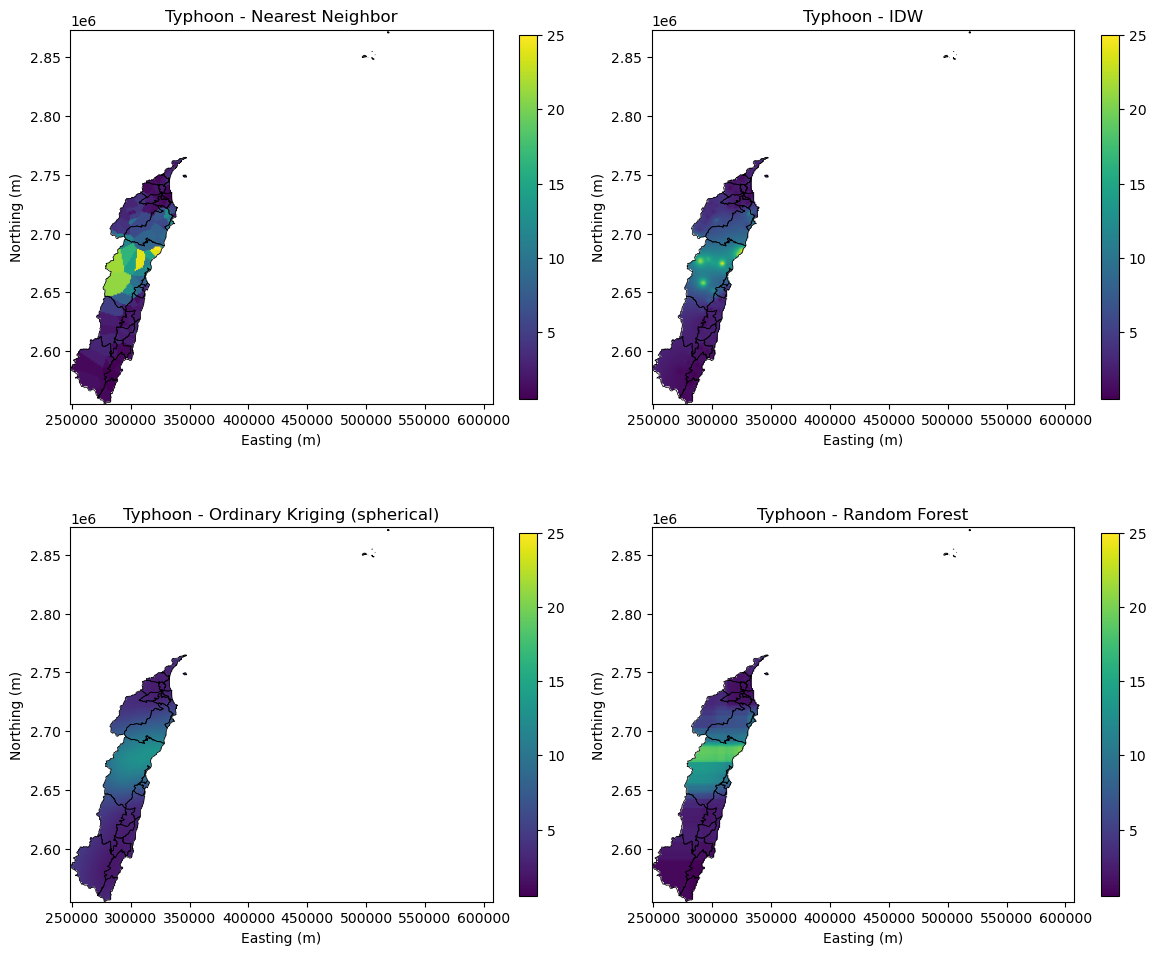

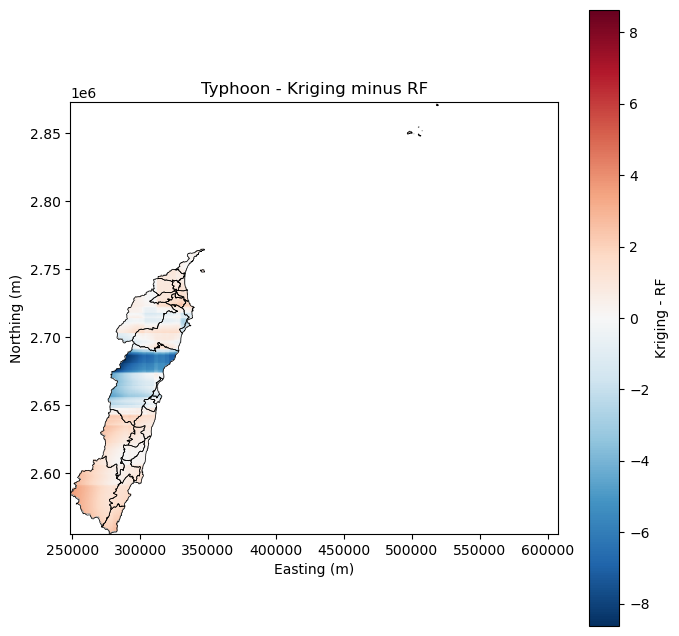

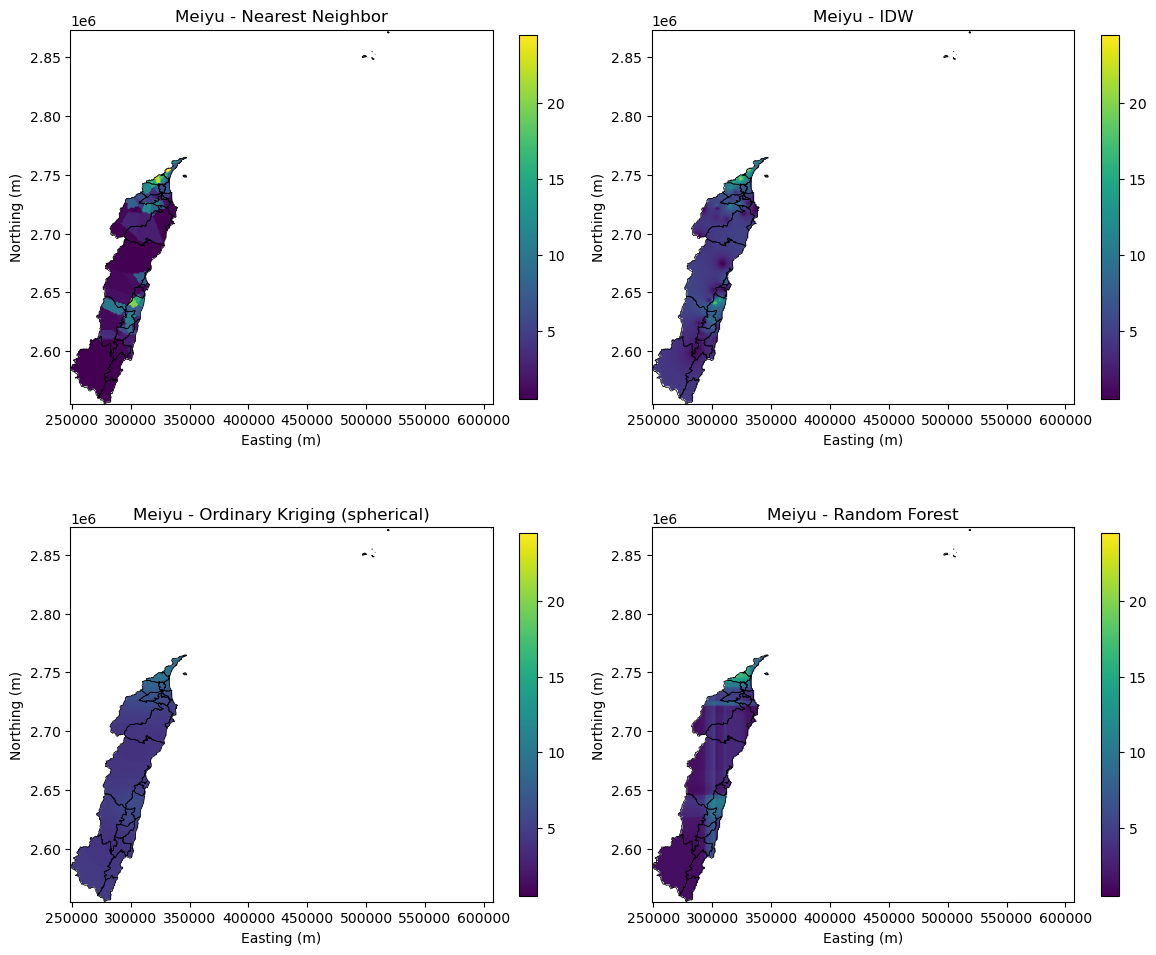

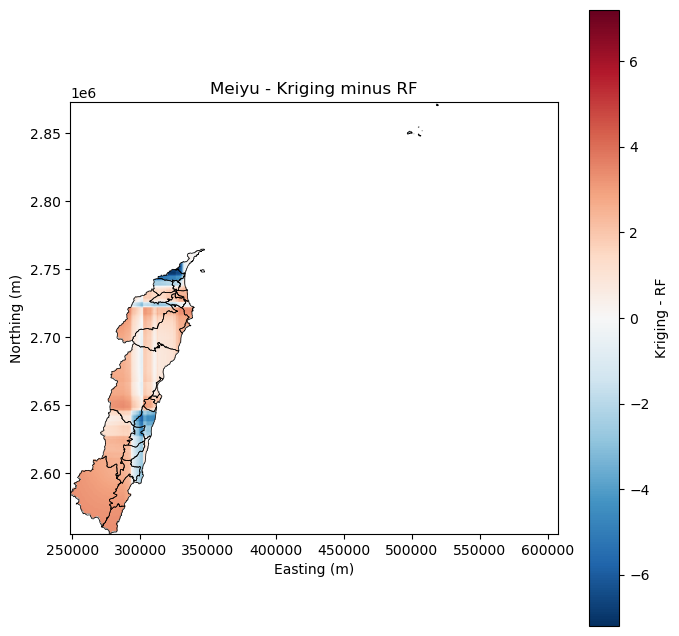

In [6]:
# =========================
# A2. 四種方法內插（兩個事件各做一次）
# 單一 cell 版
# 需要先有：
#   gdf_ty_3826
#   gdf_mei_3826
#   study_towns
#   best_model_table（若沒有，就會預設 spherical）
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from shapely.geometry import Point
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor
from pykrige.ok import OrdinaryKriging

# -------------------------
# 0. 準備資料
# -------------------------
gdf_ty = gdf_ty_3826.copy()
gdf_mei = gdf_mei_3826.copy()

for gdf in [gdf_ty, gdf_mei]:
    gdf["rain"] = pd.to_numeric(gdf["rain"], errors="coerce")

gdf_ty = gdf_ty.dropna(subset=["x", "y", "rain"]).copy()
gdf_mei = gdf_mei.dropna(subset=["x", "y", "rain"]).copy()

study_area_3826 = study_towns.to_crs(epsg=3826).copy()
study_union = study_area_3826.unary_union

# 若前面已有 A1 的最佳模型表，就沿用；否則預設 spherical
try:
    ty_model = best_model_table.loc[best_model_table["Event"] == "Typhoon", "Best_Model"].iloc[0]
    mei_model = best_model_table.loc[best_model_table["Event"] == "Meiyu", "Best_Model"].iloc[0]
except:
    ty_model = "spherical"
    mei_model = "spherical"

print("Typhoon best model:", ty_model)
print("Meiyu best model  :", mei_model)

# -------------------------
# 1. 建立 1000m 網格 + study area mask
# -------------------------
resolution = 1000  # 1000m

minx, miny, maxx, maxy = study_area_3826.total_bounds

xs = np.arange(minx, maxx + resolution, resolution)
ys = np.arange(miny, maxy + resolution, resolution)

xx, yy = np.meshgrid(xs, ys)

grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# mask：只保留研究區內格點
grid_geom = gpd.GeoSeries([Point(xy) for xy in grid_points], crs="EPSG:3826")
inside_mask = grid_geom.within(study_union).values.reshape(xx.shape)

print("Grid shape:", xx.shape)
print("Inside cells:", inside_mask.sum())

# -------------------------
# 2. 各種內插函式
# -------------------------
def interpolate_nearest(gdf, xx, yy, mask):
    pts = gdf[["x", "y"]].values
    vals = gdf["rain"].values

    interp = NearestNDInterpolator(pts, vals)
    z = interp(xx, yy).astype(float)
    z[~mask] = np.nan
    return z


def interpolate_idw(gdf, xx, yy, mask, power=2):
    obs_points = gdf[["x", "y"]].values
    obs_vals = gdf["rain"].values

    pred_points = np.column_stack([xx.ravel(), yy.ravel()])
    dists = cdist(pred_points, obs_points)

    # 避免除以 0
    dists[dists == 0] = 1e-12

    weights = 1 / (dists ** power)
    z = (weights @ obs_vals) / weights.sum(axis=1)
    z = z.reshape(xx.shape).astype(float)
    z[~mask] = np.nan
    return z


def interpolate_kriging(gdf, xs, ys, mask, variogram_model="spherical"):
    x = gdf["x"].values
    y = gdf["y"].values
    z = gdf["rain"].values

    ok = OrdinaryKriging(
        x, y, z,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False
    )

    z_krig, ss = ok.execute("grid", xs, ys)
    z_krig = np.array(z_krig, dtype=float)
    ss = np.array(ss, dtype=float)

    z_krig[~mask] = np.nan
    ss[~mask] = np.nan

    return z_krig, ss


def interpolate_rf(gdf, xx, yy, mask, n_estimators=200, min_samples_leaf=3, random_state=42):
    X_train = gdf[["x", "y"]].values
    y_train = gdf["rain"].values

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    X_pred = np.column_stack([xx.ravel(), yy.ravel()])
    z = rf.predict(X_pred).reshape(xx.shape).astype(float)
    z[~mask] = np.nan
    return z, rf

# -------------------------
# 3. 單一事件整包執行
# -------------------------
def run_all_interpolations(gdf, event_name, variogram_model):
    print(f"\n=== Running: {event_name} ===")
    print("Points:", len(gdf))
    print("Variogram model:", variogram_model)

    z_nearest = interpolate_nearest(gdf, xx, yy, inside_mask)
    z_idw = interpolate_idw(gdf, xx, yy, inside_mask, power=2)
    z_krig, z_sigma = interpolate_kriging(gdf, xs, ys, inside_mask, variogram_model=variogram_model)
    z_rf, rf_model = interpolate_rf(gdf, xx, yy, inside_mask, n_estimators=200, min_samples_leaf=3)

    return {
        "event_name": event_name,
        "nearest": z_nearest,
        "idw": z_idw,
        "kriging": z_krig,
        "sigma": z_sigma,
        "rf": z_rf,
        "rf_model": rf_model
    }

result_ty = run_all_interpolations(gdf_ty, "Typhoon", ty_model)
result_mei = run_all_interpolations(gdf_mei, "Meiyu", mei_model)

# -------------------------
# 4. 繪圖函式：2x2 比較圖
# -------------------------
def plot_four_methods(result, study_area_gdf):
    arrays = [
        result["nearest"],
        result["idw"],
        result["kriging"],
        result["rf"]
    ]
    titles = [
        "Nearest Neighbor",
        "IDW",
        f"Ordinary Kriging ({ty_model if result['event_name']=='Typhoon' else mei_model})",
        "Random Forest"
    ]

    # 同一事件共用色階
    event_min = np.nanmin([np.nanmin(a) for a in arrays])
    event_max = np.nanmax([np.nanmax(a) for a in arrays])

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for ax, arr, title in zip(axes.ravel(), arrays, titles):
        im = ax.imshow(
            arr,
            origin="lower",
            extent=[xs.min(), xs.max(), ys.min(), ys.max()],
            vmin=event_min,
            vmax=event_max
        )
        study_area_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
        ax.set_title(f"{result['event_name']} - {title}")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()

# -------------------------
# 5. 繪圖函式：Kriging - RF 差異圖
# -------------------------
def plot_difference_map(result, study_area_gdf):
    diff = result["kriging"] - result["rf"]

    vmax = np.nanmax(np.abs(diff))
    vmin = -vmax

    plt.figure(figsize=(7, 8))
    im = plt.imshow(
        diff,
        origin="lower",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )
    study_area_gdf.boundary.plot(ax=plt.gca(), color="black", linewidth=0.5)
    plt.title(f"{result['event_name']} - Kriging minus RF")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.colorbar(im, shrink=0.8, label="Kriging - RF")
    plt.tight_layout()
    plt.show()

# -------------------------
# 6. 畫圖
# -------------------------
plot_four_methods(result_ty, study_area_3826)
plot_difference_map(result_ty, study_area_3826)

plot_four_methods(result_mei, study_area_3826)
plot_difference_map(result_mei, study_area_3826)

## A2. 四種內插方法比較與分析

### (1) 四種方法空間分布比較

#### 颱風事件（Typhoon）
- **Nearest Neighbor**：呈現明顯區塊狀（blocky）分布，無法反映降雨的連續變化。
- **IDW**：具備一定平滑效果，但仍受測站分布影響，局部高值較明顯。
- **Kriging**：產生連續且平滑的降雨場，能反映空間自相關結構，結果較符合物理意義。
- **Random Forest**：可捕捉非線性變化，但出現條紋狀（banding）現象，顯示模型對格網或資料分布較敏感。

👉 **結論：**  
Kriging 在颱風事件中能提供較穩定且合理的空間分布。

---

#### 梅雨事件（Meiyu）
- **Nearest Neighbor**：同樣呈現不連續的區塊狀分布。
- **IDW**：較為平滑，但部分區域仍有局部極值。
- **Kriging**：呈現高度平滑且均勻的降雨場，符合梅雨特性。
- **Random Forest**：出現明顯條紋與不自然變化，空間一致性較差。

👉 **結論：**  
Kriging 更能表現梅雨型降雨的均勻特性。

---

### (2) Kriging 與 Random Forest 差異分析

#### 颱風事件
- 差異圖顯示明顯正負交錯區域。
- Random Forest 傾向放大局部高降雨區。
- Kriging 則呈現較平滑的過渡。

👉 **解釋：**  
颱風降雨具有高度空間變異性，Random Forest 對局部資料敏感，而 Kriging 透過空間結構進行平滑。

---

#### 梅雨事件
- 整體差異較小。
- Random Forest 仍有條紋現象。
- Kriging 結果較穩定且均勻。

👉 **解釋：**  
梅雨屬於大範圍均勻降雨，Kriging 可有效利用空間自相關結構。

---

### (3) Random Forest 條紋現象說明（重要觀察）

Random Forest 結果中出現條紋狀分布，可能原因為：
- 模型未顯式建模空間自相關
- 訓練資料數量有限
- 格網座標（X/Y）造成分裂邊界

👉 **意涵：**  
機器學習方法若未結合空間結構，可能產生不自然的空間模式。

## A3. 不確定性分析

本節以 Ordinary Kriging 所輸出的變異數（variance）作為不確定性指標，
分別對颱風事件與梅雨事件繪製 Sigma Map（以 Blues colormap 視覺化）。

Kriging variance 可反映各位置之預測不確定性：
- variance 越低，表示預測信心越高
- variance 越高，表示該區測站支撐不足或空間結構較不穩定

本節將比較兩事件之 Sigma Map 差異，
並討論不同降雨型態下 Kriging 預測信心之差異，
以及高不確定性區域之防災決策意涵。

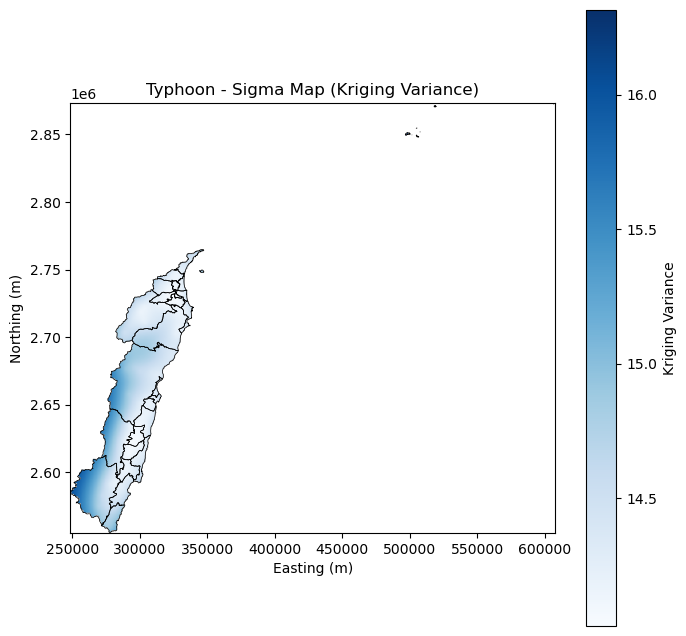

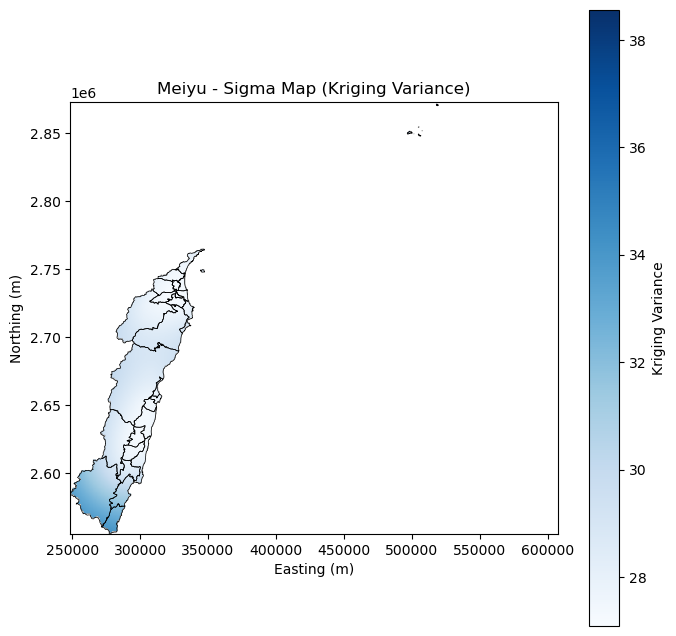

=== Sigma Summary ===

Typhoon
min: 14.0239
max: 16.3151
mean: 14.5937
std: 0.4149

Meiyu
min: 27.0915
max: 38.5591
mean: 29.0065
std: 1.6427


In [7]:
# =========================
# A3. 不確定性分析
# 需要先有：
#   result_ty
#   result_mei
#   study_area_3826
#   xs, ys
# =========================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. 繪圖函式：Sigma Map
# -------------------------
def plot_sigma_map(result, study_area_gdf, xs, ys):
    sigma = result["sigma"]

    plt.figure(figsize=(7, 8))
    im = plt.imshow(
        sigma,
        origin="lower",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        cmap="Blues"
    )
    study_area_gdf.boundary.plot(ax=plt.gca(), color="black", linewidth=0.5)
    plt.title(f"{result['event_name']} - Sigma Map (Kriging Variance)")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.colorbar(im, shrink=0.8, label="Kriging Variance")
    plt.tight_layout()
    plt.show()

# -------------------------
# 2. 畫兩事件 Sigma Map
# -------------------------
plot_sigma_map(result_ty, study_area_3826, xs, ys)
plot_sigma_map(result_mei, study_area_3826, xs, ys)

# -------------------------
# 3. 摘要統計（方便比較）
# -------------------------
sigma_ty = result_ty["sigma"]
sigma_mei = result_mei["sigma"]

summary_sigma = {
    "Typhoon": {
        "min": np.nanmin(sigma_ty),
        "max": np.nanmax(sigma_ty),
        "mean": np.nanmean(sigma_ty),
        "std": np.nanstd(sigma_ty)
    },
    "Meiyu": {
        "min": np.nanmin(sigma_mei),
        "max": np.nanmax(sigma_mei),
        "mean": np.nanmean(sigma_mei),
        "std": np.nanstd(sigma_mei)
    }
}

print("=== Sigma Summary ===")
for event, stats in summary_sigma.items():
    print(f"\n{event}")
    for k, v in stats.items():
        print(f"{k}: {v:.4f}")

兩事件的 Sigma Map 顯示明顯差異：梅雨事件的 variance 整體顯著高於颱風事件（平均約 29.01 vs 14.59，且變異範圍亦較大），表示其 Kriging 預測不確定性較高。此現象主要因梅雨測站數較少（81 vs 137），導致空間支撐不足；此外，梅雨降雨雖較均勻，但在資料稀疏情況下，Kriging 難以穩定估計空間結構。相對而言，颱風事件測站較密集，使 variance 較低，預測信心較高。

因此，本案例中為颱風事件的 Kriging 預測信心較高（非僅由降雨型態決定，而與測站密度密切相關）。若我是指揮官，面對高 variance 區域，會將其視為高不確定性區，優先加密監測、參考鄰近測站資料，並採取較保守的防災決策。

Random Forest 雖可進行預測，但其模型未顯式建模空間自相關，亦不直接輸出具統計意義的 variance，因此無法像 Kriging 一樣提供可靠的不確定性量化資訊。

### 綜合結論

整體而言：
- **Kriging** 能有效利用空間自相關，產生連續且具物理意義的降雨場。
- **Random Forest** 雖可捕捉非線性關係，但在空間連續性上較弱。
- 在均勻降雨（梅雨）情境下，Kriging 表現特別穩定。
- 在高變異降雨（颱風）情境下，Random Forest 容易放大局部極值。

👉 **結論：**  
在降雨空間內插問題中，地統計方法（Kriging）通常較機器學習方法更具空間一致性與解釋性。

### A4. GeoTIFF 輸出（擇一事件即可）

1. 將 Kriging 結果儲存為 `kriging_rainfall.tif`（EPSG:3826）
2. 將 Kriging variance 儲存為 `kriging_variance.tif`（EPSG:3826）
3. 將 RF 結果儲存為 `rf_rainfall.tif`（EPSG:3826）
4. **注意 y 軸翻轉**：numpy row 0 = south → GeoTIFF row 0 = north（需 `np.flipud()`）

本研究選擇颱風事件作為 GeoTIFF 輸出案例，因其測站數較多、空間分布較完整，且插值結果較具代表性，適合作為後續 GIS 展示與空間分析之基礎資料。

In [8]:
# =========================
# A4. GeoTIFF 輸出（選 Typhoon）
# 需要先有：
#   result_ty
#   xs, ys
#   RASTER_DIR
# =========================

import os
import numpy as np
import rasterio
from rasterio.transform import from_origin

# -------------------------
# 1. 輸出用函式
# -------------------------
def export_geotiff(array, xs, ys, output_path, crs="EPSG:3826"):
    """
    將 2D numpy array 輸出為 GeoTIFF
    注意：
    - numpy row 0 在 south（畫圖時常用 origin='lower'）
    - GeoTIFF row 0 在 north
    - 因此需 np.flipud()
    """

    # 格網解析度
    xres = xs[1] - xs[0]
    yres = ys[1] - ys[0]

    # GeoTIFF 左上角座標
    west = xs.min()
    north = ys.max()

    transform = from_origin(west, north, xres, yres)

    # 翻轉 y 軸方向
    out_array = np.flipud(array).astype("float32")

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=out_array.shape[0],
        width=out_array.shape[1],
        count=1,
        dtype="float32",
        crs=crs,
        transform=transform,
        nodata=np.nan
    ) as dst:
        dst.write(out_array, 1)

    print("Saved:", output_path)

# -------------------------
# 2. 準備輸出資料（Typhoon）
# -------------------------
kriging_rainfall = result_ty["kriging"]
kriging_variance = result_ty["sigma"]
rf_rainfall = result_ty["rf"]

# -------------------------
# 3. 輸出 GeoTIFF
# -------------------------
kriging_rainfall_path = os.path.join(RASTER_DIR, "kriging_rainfall.tif")
kriging_variance_path = os.path.join(RASTER_DIR, "kriging_variance.tif")
rf_rainfall_path = os.path.join(RASTER_DIR, "rf_rainfall.tif")

export_geotiff(kriging_rainfall, xs, ys, kriging_rainfall_path)
export_geotiff(kriging_variance, xs, ys, kriging_variance_path)
export_geotiff(rf_rainfall, xs, ys, rf_rainfall_path)

print("\nA4 complete.")
print("Output files:")
print("-", kriging_rainfall_path)
print("-", kriging_variance_path)
print("-", rf_rainfall_path)

Saved: C:\Users\User\CascadeProjects\week6_HW\outputs\rasters\kriging_rainfall.tif
Saved: C:\Users\User\CascadeProjects\week6_HW\outputs\rasters\kriging_variance.tif
Saved: C:\Users\User\CascadeProjects\week6_HW\outputs\rasters\rf_rainfall.tif

A4 complete.
Output files:
- C:\Users\User\CascadeProjects\week6_HW\outputs\rasters\kriging_rainfall.tif
- C:\Users\User\CascadeProjects\week6_HW\outputs\rasters\kriging_variance.tif
- C:\Users\User\CascadeProjects\week6_HW\outputs\rasters\rf_rainfall.tif


## A5. 跨事件綜合比較

本節整理颱風事件與梅雨事件之最佳 variogram 模型參數，
比較兩事件在 sill、range、nugget 與最佳模型上的差異，
並進一步討論若未來只能採用單一組 variogram 參數，
可能的選擇方式及其風險。

In [9]:
# =========================
# A5. 跨事件綜合比較
# 需要先有：
#   best_model_table
# =========================

import pandas as pd

# 從 best_model_table 取參數
ty_row = best_model_table[best_model_table["Event"] == "Typhoon"].iloc[0]
mei_row = best_model_table[best_model_table["Event"] == "Meiyu"].iloc[0]

a5_compare = pd.DataFrame({
    "參數": ["Sill", "Range", "Nugget", "Best Model"],
    "事件1（Typhoon）": [
        round(ty_row["Total_Sill"], 4),
        round(ty_row["Range"], 4),
        round(ty_row["Nugget"], 4),
        ty_row["Best_Model"]
    ],
    "事件2（Meiyu）": [
        round(mei_row["Total_Sill"], 4),
        round(mei_row["Range"], 4),
        round(mei_row["Nugget"], 4),
        mei_row["Best_Model"]
    ],
    "差異原因": [
        "Typhoon 的 sill 較高，表示整體空間變異較大；Meiyu 較低，表示降雨場較平緩。",
        "Typhoon 的 range 較長，表示空間影響範圍較廣；Meiyu 較短，表示降雨較局部化。",
        "Meiyu 的 nugget 較高，代表短距離變異較強，可能反映局部對流或測站支撐不足。",
        "兩事件最佳模型皆為 spherical，表示在本研究資料下，球狀模型較能描述空間自相關結構。"
    ]
})

print("=== A5 Variogram Cross-Event Comparison ===")
display(a5_compare)

=== A5 Variogram Cross-Event Comparison ===


,參數,事件1（Typhoon）,事件2（Meiyu）,差異原因
0,Sill,45.3735,26.8409,Typhoon 的 sill 較高，表示整體空間變異較大；Meiyu 較低，表示降雨場較平緩。
1,Range,66499.1243,18585.3157,Typhoon 的 range 較長，表示空間影響範圍較廣；Meiyu 較短，表示降雨較局部化。
2,Nugget,0.0,10.2263,Meiyu 的 nugget 較高，代表短距離變異較強，可能反映局部對流或測站支撐不足。
3,Best Model,spherical,spherical,兩事件最佳模型皆為 spherical，表示在本研究資料下，球狀模型較能描述空間自相關結構。


由跨事件參數比較可見，颱風事件之 sill 較高，表示其整體空間變異較大；range 亦顯著較長，顯示颱風降雨影響範圍較廣。相較之下，梅雨事件之 sill 較低、range 較短，表示降雨空間分布較局部化。此外，梅雨事件之 nugget 明顯高於颱風事件，反映其短距離變異較強，與其偏對流化之降雨特性一致。雖然兩事件最佳模型皆為 spherical，但其參數差異仍顯示不同降雨型態具有不同空間結構。

若只能使用一組 variogram 參數，我會選擇 spherical 模型，並採用介於兩事件之間的折衷參數，以兼顧不同事件型態。然而此做法有風險，因為 variogram 參數代表特定事件的空間結構；若用同一組參數處理所有事件，可能使颱風降雨被過度平滑，或使局部對流型降雨之空間變異被錯誤估計。因此，variogram 仍應依事件特性個別校估。